In [94]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_lr_bert_log_file(metrics_csv_1b, metrics_csv_2b, metrics_csv_1e, metrics_csv_2e, coords, metrics_img, model):
    df1b = pd.read_csv(metrics_csv_1b)
    df2b = pd.read_csv(metrics_csv_2b)
    df1e = pd.read_csv(metrics_csv_1e)
    df2e = pd.read_csv(metrics_csv_2e)

    sns.set_theme(style="darkgrid")
    fig, ((ax1b, ax1e), (ax2b, ax2e)) = plt.subplots(2, 2, figsize=(16, 9))  # 2 rows, 2 columns
    fontsize = 14

    # Plot 1: Training Metrics (binding)
    ax1b.plot(df1b['Epoch'], df1b[f'Train {model} RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1b.plot(df2b['Epoch'], df2b[f'Train {model} RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1b.tick_params(axis='x', labelsize=fontsize)    
    ax1b.set_xlim(-50, 1050)
    ax1b.set_ylabel('RMSE', fontsize=fontsize)
    ax1b.tick_params(axis='y', labelsize=fontsize)
    ax1b.set_ylim(-0.1, 3)
    ax1b.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1b.set_title('Training - Binding', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding)
    ax2b.plot(df1b['Epoch'], df1b[f'Test {model} RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2b.plot(df2b['Epoch'], df2b[f'Test {model} RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2b.set_xlabel('Epochs', fontsize=fontsize)
    ax2b.tick_params(axis='x', labelsize=fontsize)
    ax2b.set_xlim(-50, 1050)
    ax2b.set_ylabel('RMSE', fontsize=fontsize)
    ax2b.tick_params(axis='y', labelsize=fontsize)
    ax2b.set_ylim(-0.1, 3)
    ax2b.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2b.set_title('Testing - Binding', loc='right', fontsize=fontsize)

    # Plot 3: Training Metrics (expression)
    ax1e.plot(df1e['Epoch'], df1e[f'Train {model} RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1e.plot(df2e['Epoch'], df2e[f'Train {model} RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1e.tick_params(axis='x', labelsize=fontsize)    
    ax1e.set_xlim(-50, 1050)
    ax1e.set_ylabel('')
    ax1e.tick_params(axis='y', labelsize=fontsize)
    ax1e.set_ylim(-0.1, 3)
    ax1e.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1e.set_title('Training - Expression', loc='right', fontsize=fontsize)

    # Plot 4: Testing Metrics (expression)
    ax2e.plot(df1e['Epoch'], df1e[f'Test {model} RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2e.plot(df2e['Epoch'], df2e[f'Test {model} RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2e.set_xlabel('Epochs', fontsize=fontsize)
    ax2e.tick_params(axis='x', labelsize=fontsize)
    ax2e.set_xlim(-50, 1050)
    ax2e.set_ylabel('')
    ax2e.tick_params(axis='y', labelsize=fontsize)
    ax2e.set_ylim(-0.1, 3)
    ax2e.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2e.set_title('Testing - Expression', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1b_rmse = find_best_epoch(metrics_csv_1b, f'Test {model} RMSE')
    best_df2b_rmse = find_best_epoch(metrics_csv_2b, f'Test {model} RMSE')
    best_df1e_rmse = find_best_epoch(metrics_csv_1e, f'Test {model} RMSE')
    best_df2e_rmse = find_best_epoch(metrics_csv_2e, f'Test {model} RMSE')
    
    print("Best test RMSE at epoch x:")
    print("- Binding:")
    print(f"\tADAM, LR=1e-4: epoch {best_df1b_rmse[0]}, rmse {best_df1b_rmse[1]:.4f}")
    print(f"\tADAM, LR=1e-5: epoch {best_df2b_rmse[0]}, rmse {best_df2b_rmse[1]:.4f}")
    print("- Expression:")
    print(f"\tADAM, LR=1e-4: epoch {best_df1e_rmse[0]}, rmse {best_df1e_rmse[1]:.4f}")
    print(f"\tADAM, LR=1e-5: epoch {best_df2e_rmse[0]}, rmse {best_df2e_rmse[1]:.4f}")

    ax2b.annotate(
        f'({best_df1b_rmse[0]}, {best_df1b_rmse[1]:.4f})', best_df1b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2b.annotate(
        f'({best_df2b_rmse[0]}, {best_df2b_rmse[1]:.4f})', best_df2b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2e.annotate(
        f'({best_df1e_rmse[0]}, {best_df1e_rmse[1]:.4f})', best_df1e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2e.annotate(
        f'({best_df2e_rmse[0]}, {best_df2e_rmse[1]:.4f})', best_df2e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_lr_log_file(metrics_csv_1b, metrics_csv_2b, metrics_csv_1e, metrics_csv_2e, coords, metrics_img):
    df1b = pd.read_csv(metrics_csv_1b)
    df2b = pd.read_csv(metrics_csv_2b)
    df1e = pd.read_csv(metrics_csv_1e)
    df2e = pd.read_csv(metrics_csv_2e)

    sns.set_theme(style="darkgrid")
    fig, ((ax1b, ax1e), (ax2b, ax2e)) = plt.subplots(2, 2, figsize=(16, 9))  # 2 rows, 2 columns
    fontsize = 14

    # Plot 1: Training Metrics (binding)
    ax1b.plot(df1b['Epoch'], df1b[f'Train RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1b.plot(df2b['Epoch'], df2b[f'Train RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1b.tick_params(axis='x', labelsize=fontsize)    
    ax1b.set_xlim(-50, 1050)
    ax1b.set_ylabel('RMSE', fontsize=fontsize)
    ax1b.tick_params(axis='y', labelsize=fontsize)
    ax1b.set_ylim(-0.1, 3)
    ax1b.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1b.set_title('Training - Binding', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding)
    ax2b.plot(df1b['Epoch'], df1b[f'Test RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2b.plot(df2b['Epoch'], df2b[f'Test RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2b.set_xlabel('Epochs', fontsize=fontsize)
    ax2b.tick_params(axis='x', labelsize=fontsize)
    ax2b.set_xlim(-50, 1050)
    ax2b.set_ylabel('RMSE', fontsize=fontsize)
    ax2b.tick_params(axis='y', labelsize=fontsize)
    ax2b.set_ylim(-0.1, 3)
    ax2b.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2b.set_title('Testing - Binding', loc='right', fontsize=fontsize)

    # Plot 3: Training Metrics (expression)
    ax1e.plot(df1e['Epoch'], df1e[f'Train RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1e.plot(df2e['Epoch'], df2e[f'Train RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1e.tick_params(axis='x', labelsize=fontsize)    
    ax1e.set_xlim(-50, 1050)
    ax1e.set_ylabel('')
    ax1e.tick_params(axis='y', labelsize=fontsize)
    ax1e.set_ylim(-0.1, 3)
    ax1e.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1e.set_title('Training - Expression', loc='right', fontsize=fontsize)

    # Plot 4: Testing Metrics (expression)
    ax2e.plot(df1e['Epoch'], df1e[f'Test RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2e.plot(df2e['Epoch'], df2e[f'Test RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2e.set_xlabel('Epochs', fontsize=fontsize)
    ax2e.tick_params(axis='x', labelsize=fontsize)
    ax2e.set_xlim(-50, 1050)
    ax2e.set_ylabel('')
    ax2e.tick_params(axis='y', labelsize=fontsize)
    ax2e.set_ylim(-0.1, 3)
    ax2e.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2e.set_title('Testing - Expression', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1b_rmse = find_best_epoch(metrics_csv_1b, f'Test RMSE')
    best_df2b_rmse = find_best_epoch(metrics_csv_2b, f'Test RMSE')
    best_df1e_rmse = find_best_epoch(metrics_csv_1e, f'Test RMSE')
    best_df2e_rmse = find_best_epoch(metrics_csv_2e, f'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print("- Binding:")
    print(f"\tADAM, LR=1e-4: epoch {best_df1b_rmse[0]}, rmse {best_df1b_rmse[1]:.4f}")
    print(f"\tADAM, LR=1e-5: epoch {best_df2b_rmse[0]}, rmse {best_df2b_rmse[1]:.4f}")
    print("- Expression:")
    print(f"\tADAM, LR=1e-4: epoch {best_df1e_rmse[0]}, rmse {best_df1e_rmse[1]:.4f}")
    print(f"\tADAM, LR=1e-5: epoch {best_df2e_rmse[0]}, rmse {best_df2e_rmse[1]:.4f}")

    ax2b.annotate(
        f'({best_df1b_rmse[0]}, {best_df1b_rmse[1]:.4f})', best_df1b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2b.annotate(
        f'({best_df2b_rmse[0]}, {best_df2b_rmse[1]:.4f})', best_df2b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2e.annotate(
        f'({best_df1e_rmse[0]}, {best_df1e_rmse[1]:.4f})', best_df1e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2e.annotate(
        f'({best_df2e_rmse[0]}, {best_df2e_rmse[1]:.4f})', best_df2e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

---
### BERT-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 407, rmse 1.0088
	ADAM, LR=1e-5: epoch 999, rmse 1.1019
- Expression:
	ADAM, LR=1e-4: epoch 939, rmse 0.5604
	ADAM, LR=1e-5: epoch 909, rmse 0.5908


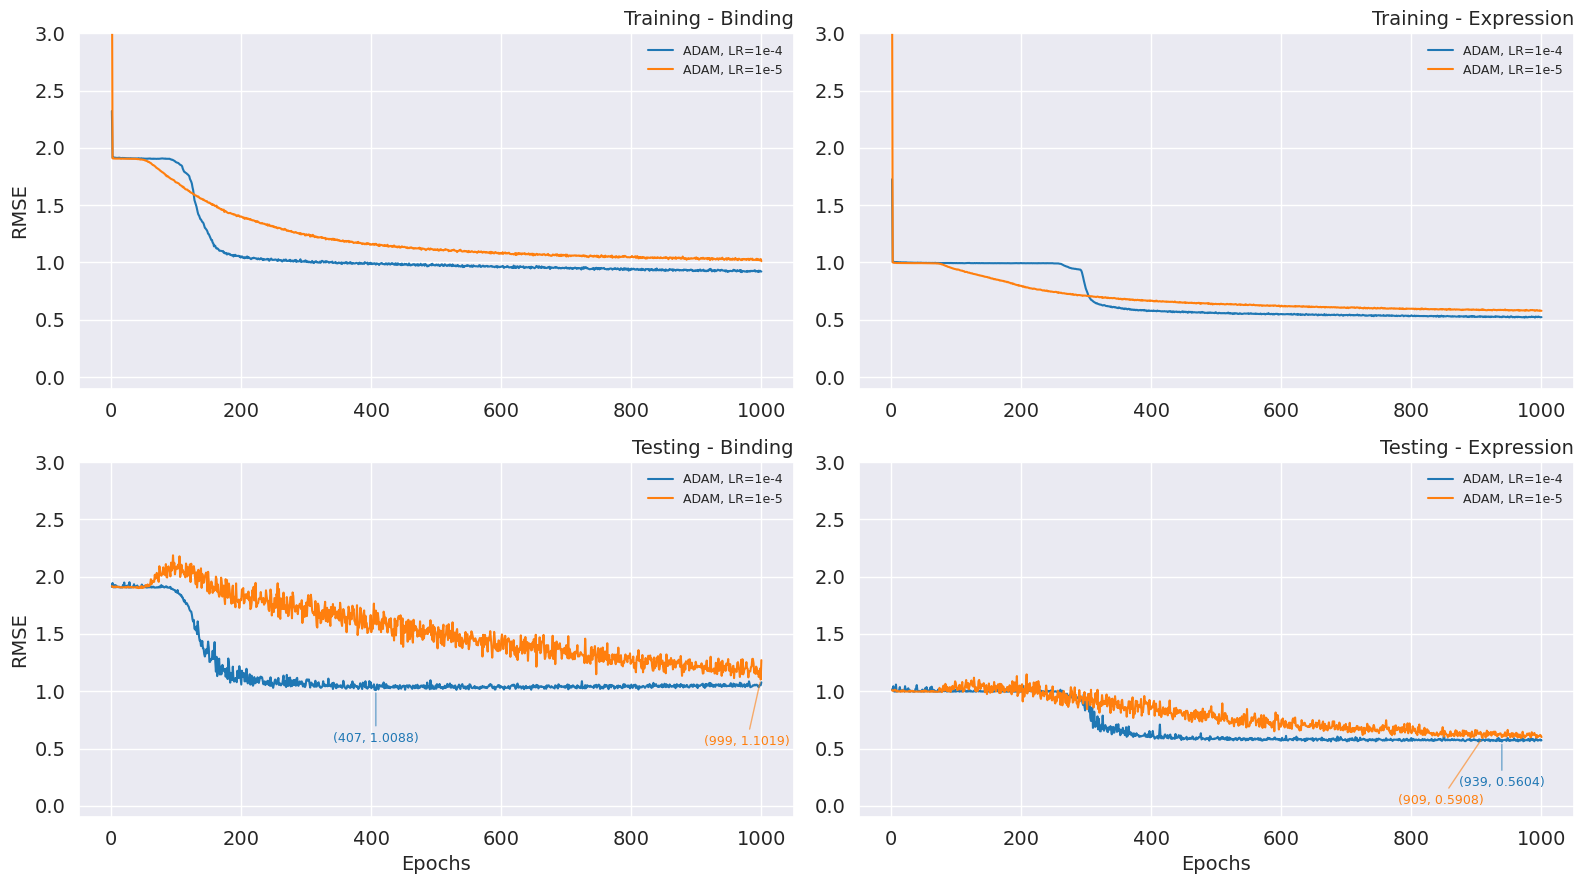

In [95]:
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-binding-2024-12-07_02-56/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-05.bert_blstm-DMS_OLD-binding-2024-12-05_18-11/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-expression-2024-12-07_02-58/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-05.bert_blstm-DMS_OLD-expression-2024-12-05_18-12/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_blstm"
coords = {
    "B, ADAM, LR:1e-4": (0,-30),
    "B, ADAM, LR:1e-5": (-10,-40),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (-30,-40)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "BLSTM")

---
### BERT-GCN Initialized w/ BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 687, rmse 1.1326
	ADAM, LR=1e-5: epoch 6, rmse 1.9094
- Expression:
	ADAM, LR=1e-4: epoch 995, rmse 0.6230
	ADAM, LR=1e-5: epoch 16, rmse 1.0393


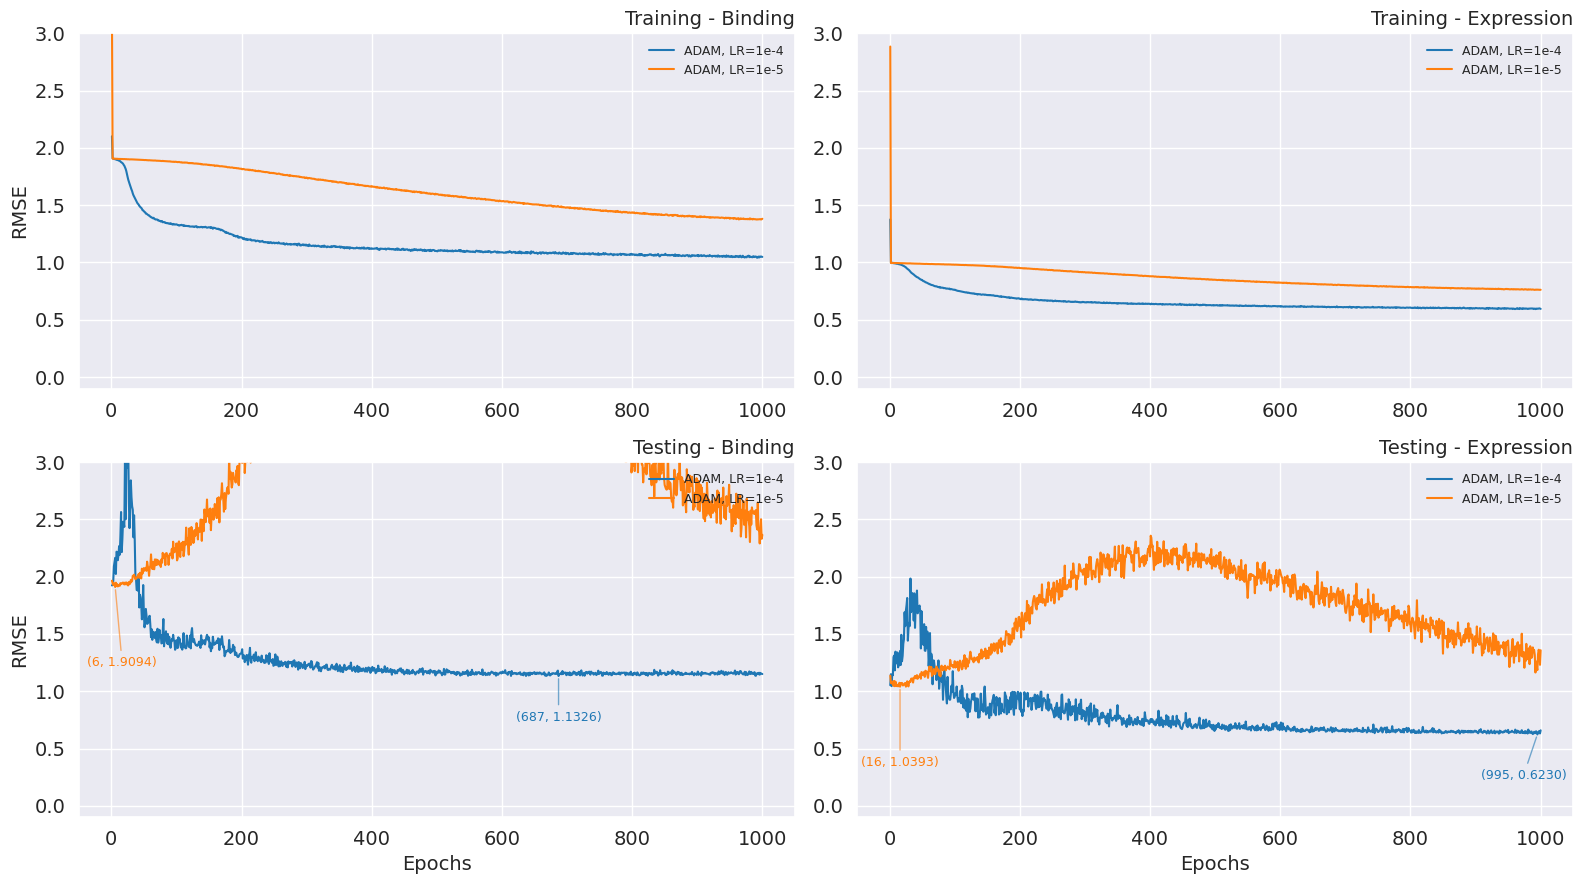

In [96]:
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-binding-2024-12-05_17-52/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-binding-2024-12-05_17-49/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-expression-2024-12-05_17-51/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-expression-2024-12-05_17-50/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.old"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (5,-50),
    "E, ADAM, LR:1e-4": (-10,-25),
    "E, ADAM, LR:1e-5": (0,-50)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "GCN")

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 760, rmse 1.1318
	ADAM, LR=1e-5: epoch 955, rmse 1.3986
- Expression:
	ADAM, LR=1e-4: epoch 671, rmse 0.6237
	ADAM, LR=1e-5: epoch 995, rmse 0.6775


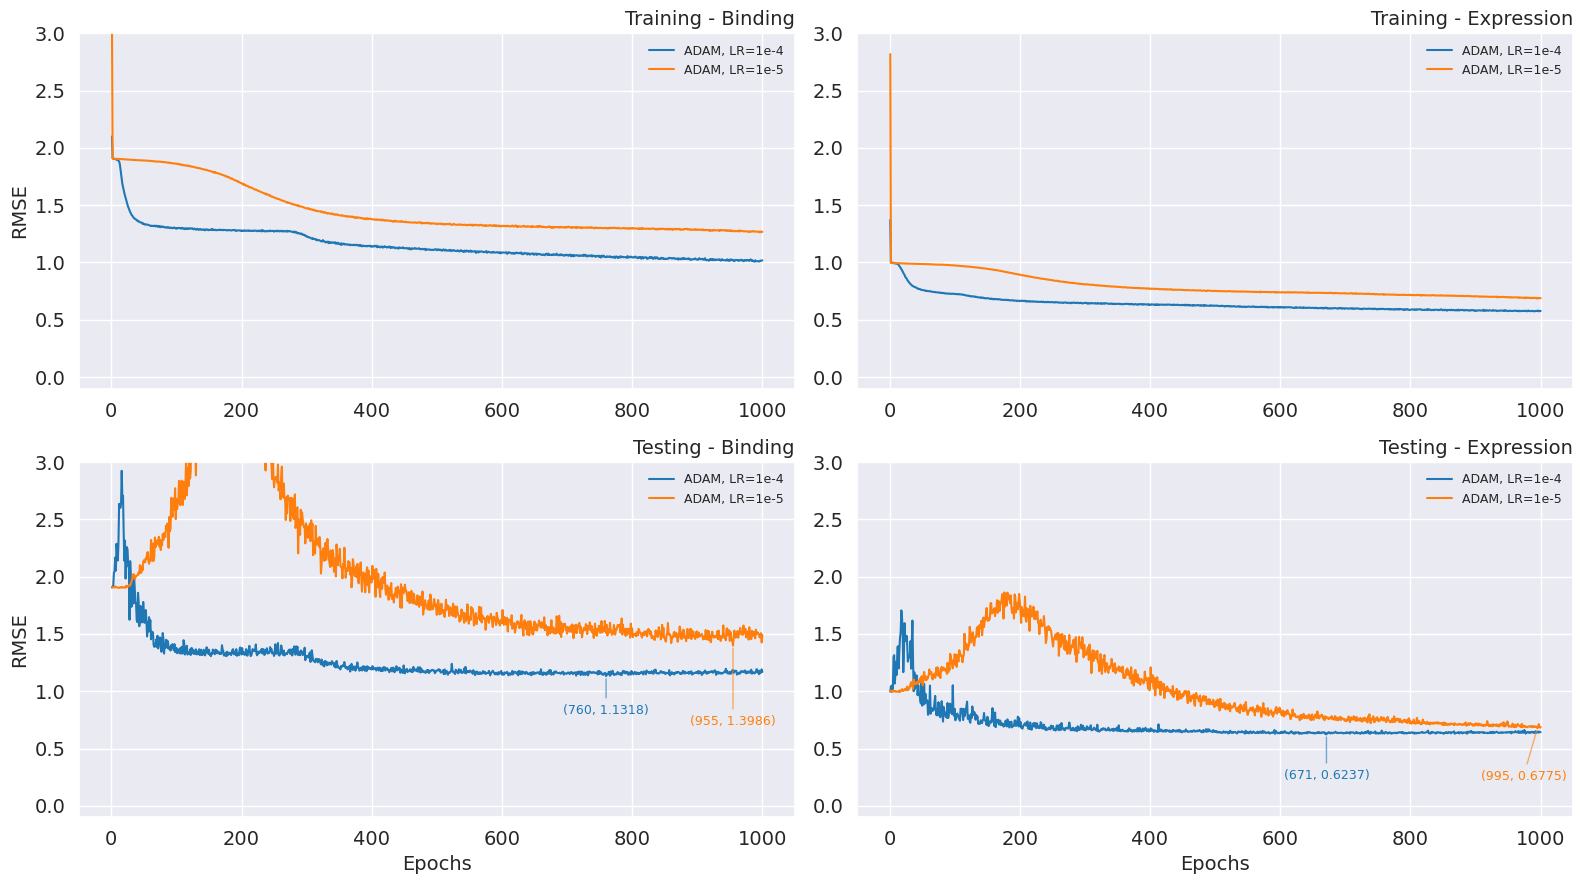

In [97]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-binding-2025-01-04_00-28/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-binding-2025-01-03_23-00/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-expression-2025-01-04_00-32/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-expression-2025-01-03_20-46/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (0,-50),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (-10,-30)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "GCN")

In [ ]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../"
b_adam_lr_1e_neg_5 = "../../"
e_adam_lr_1e_neg_4 = "../../"
e_adam_lr_1e_neg_5 = "../../"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-50),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (-10,-30)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "GCN")

--- 
### ESM-FCN

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 76, rmse 0.5235
	ADAM, LR=1e-5: epoch 965, rmse 0.5185
- Expression:
	ADAM, LR=1e-4: epoch 233, rmse 0.3145
	ADAM, LR=1e-5: epoch 985, rmse 0.3172


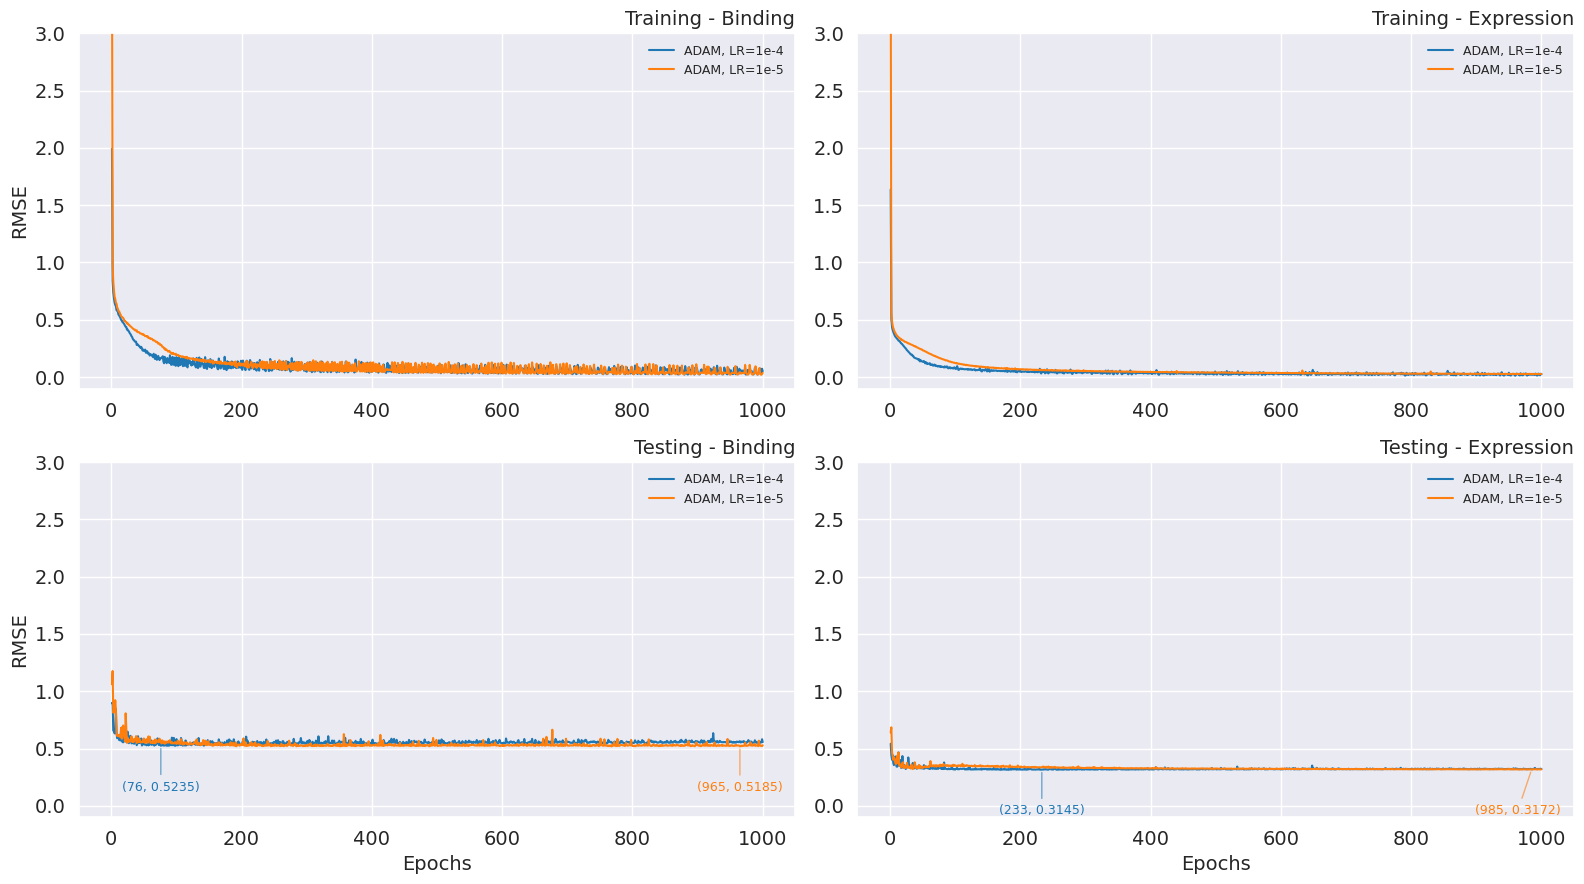

In [102]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-binding-2024-12-05_04-12/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-expression-2024-12-04_17-56/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_fcn"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (-10,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-GCN

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 109, rmse 0.5570
	ADAM, LR=1e-5: epoch 576, rmse 0.5347
- Expression:
	ADAM, LR=1e-4: epoch 189, rmse 0.3323
	ADAM, LR=1e-5: epoch 974, rmse 0.3213


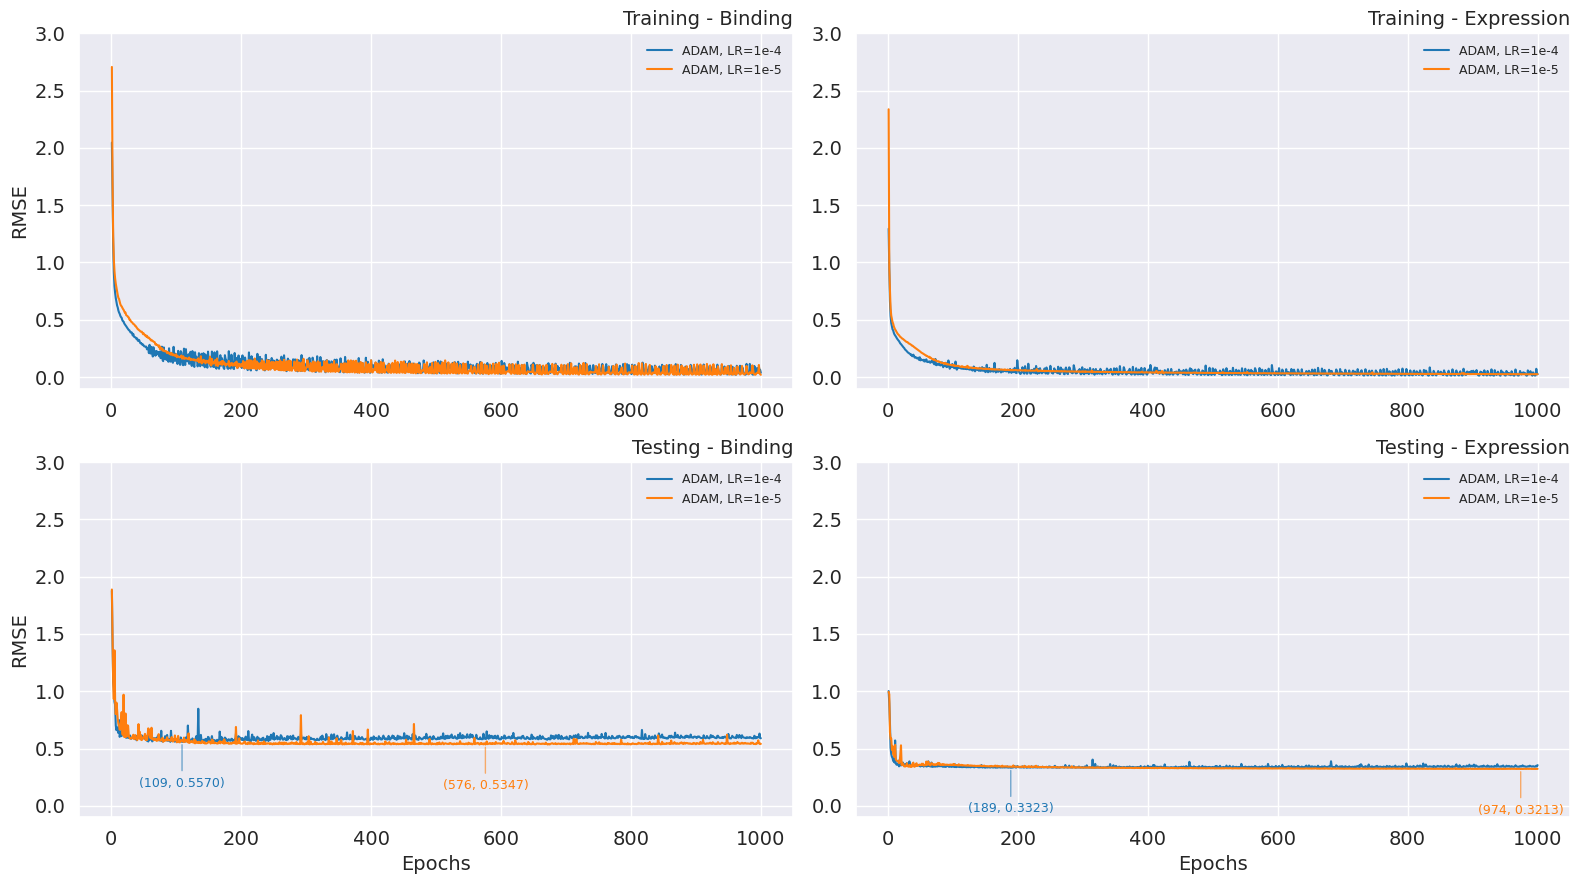

In [104]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-binding-2024-12-09_00-32/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2024-12-07_09-12/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-expression-2024-12-09_00-31/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2024-12-07_09-13/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.old"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (0,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 115, rmse 0.5459
	ADAM, LR=1e-5: epoch 674, rmse 0.5201
- Expression:
	ADAM, LR=1e-4: epoch 188, rmse 0.3235
	ADAM, LR=1e-5: epoch 997, rmse 0.3184


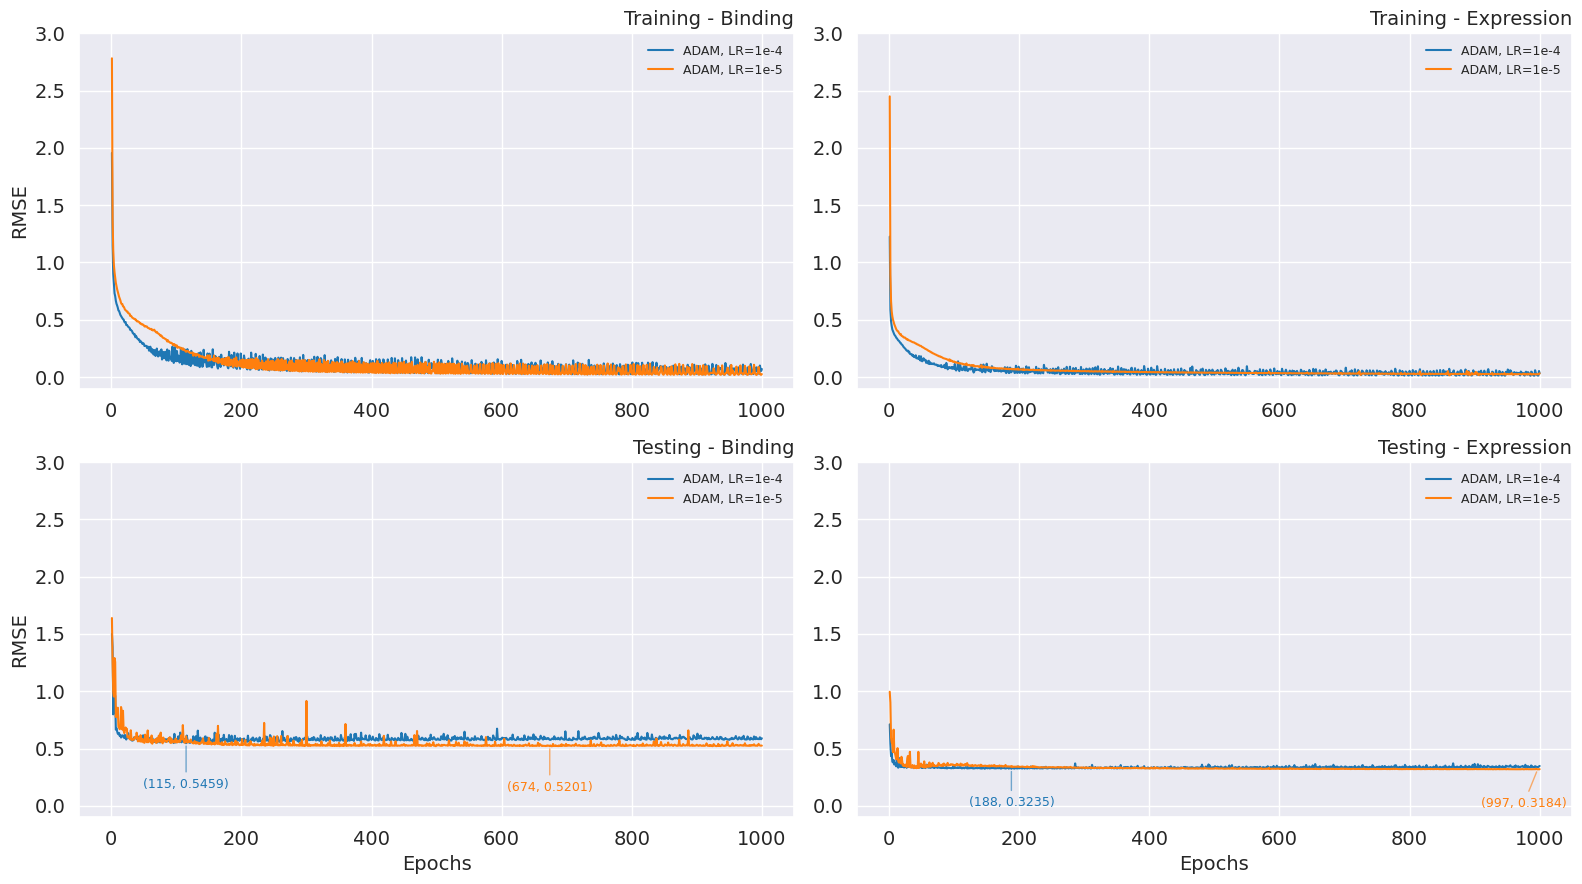

In [105]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-binding-2025-01-07_20-54/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-expression-2025-01-07_20-54/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-07_20-54/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-5": (-10,-20)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

In [ ]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../"
b_adam_lr_1e_neg_5 = "../../"
e_adam_lr_1e_neg_4 = "../../"
e_adam_lr_1e_neg_5 = "../../"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-5": (-10,-20)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-BLSTM

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 99, rmse 0.5362
	ADAM, LR=1e-5: epoch 329, rmse 0.5242
- Expression:
	ADAM, LR=1e-4: epoch 233, rmse 0.3227
	ADAM, LR=1e-5: epoch 907, rmse 0.3202


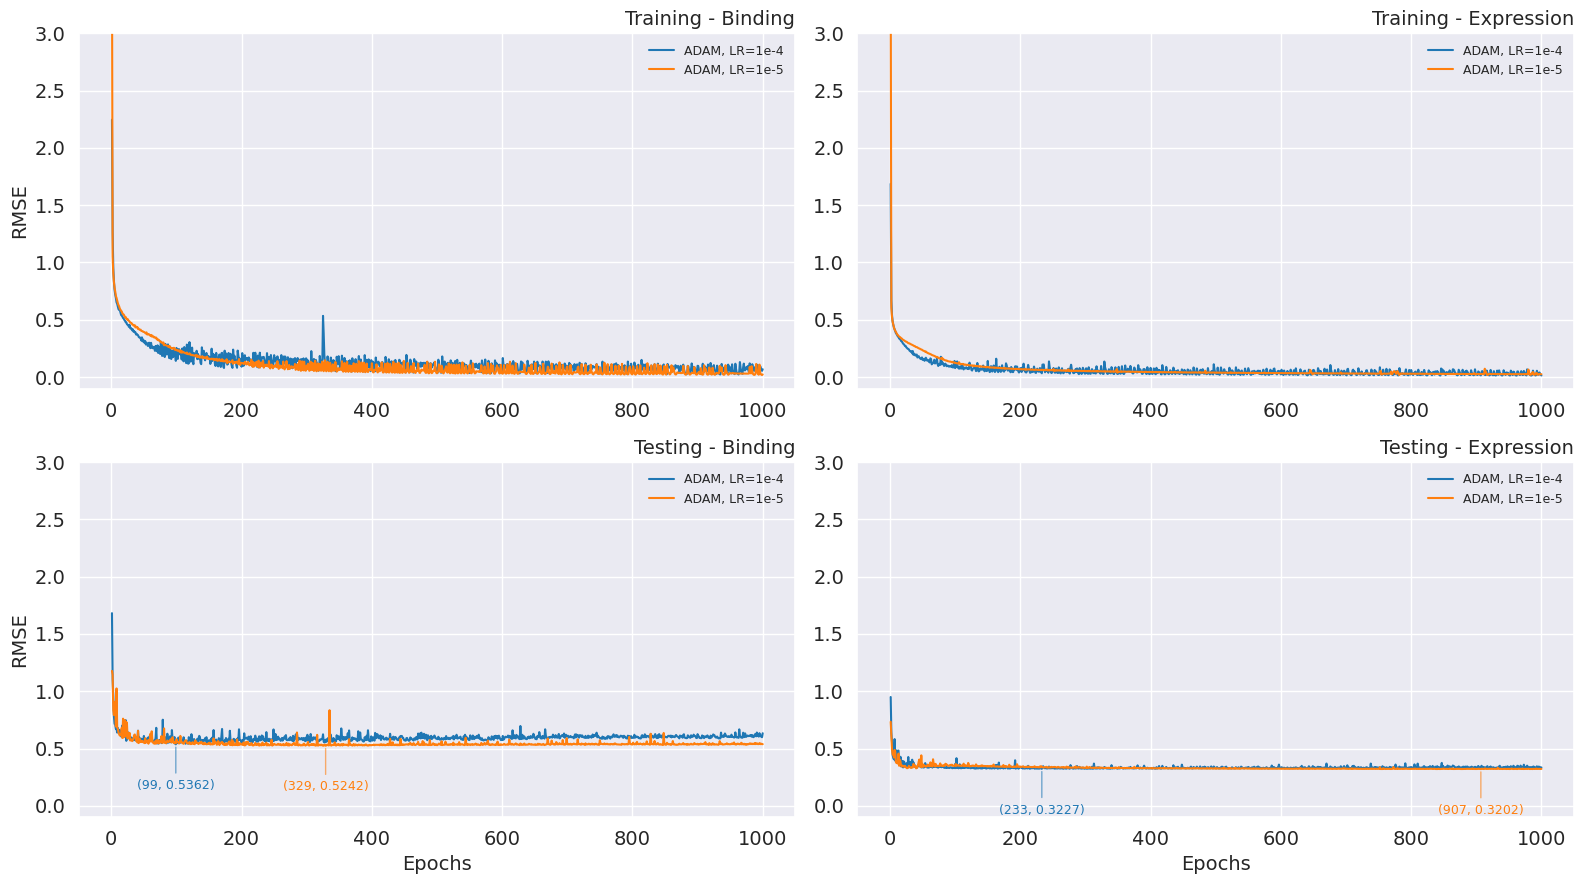

In [106]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-04.esm_blstm-DMS_OLD-binding-2024-12-17_10-42/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-binding-2024-12-07_08-58/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-04.esm_blstm-DMS_OLD-expression-2024-12-17_10-43/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-expression-2024-12-07_09-00/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (0,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 119, rmse 0.5954
	ADAM, LR=1e-5: epoch 447, rmse 0.6573
- Expression:
	ADAM, LR=1e-4: epoch 211, rmse 0.3383
	ADAM, LR=1e-5: epoch 952, rmse 0.3486


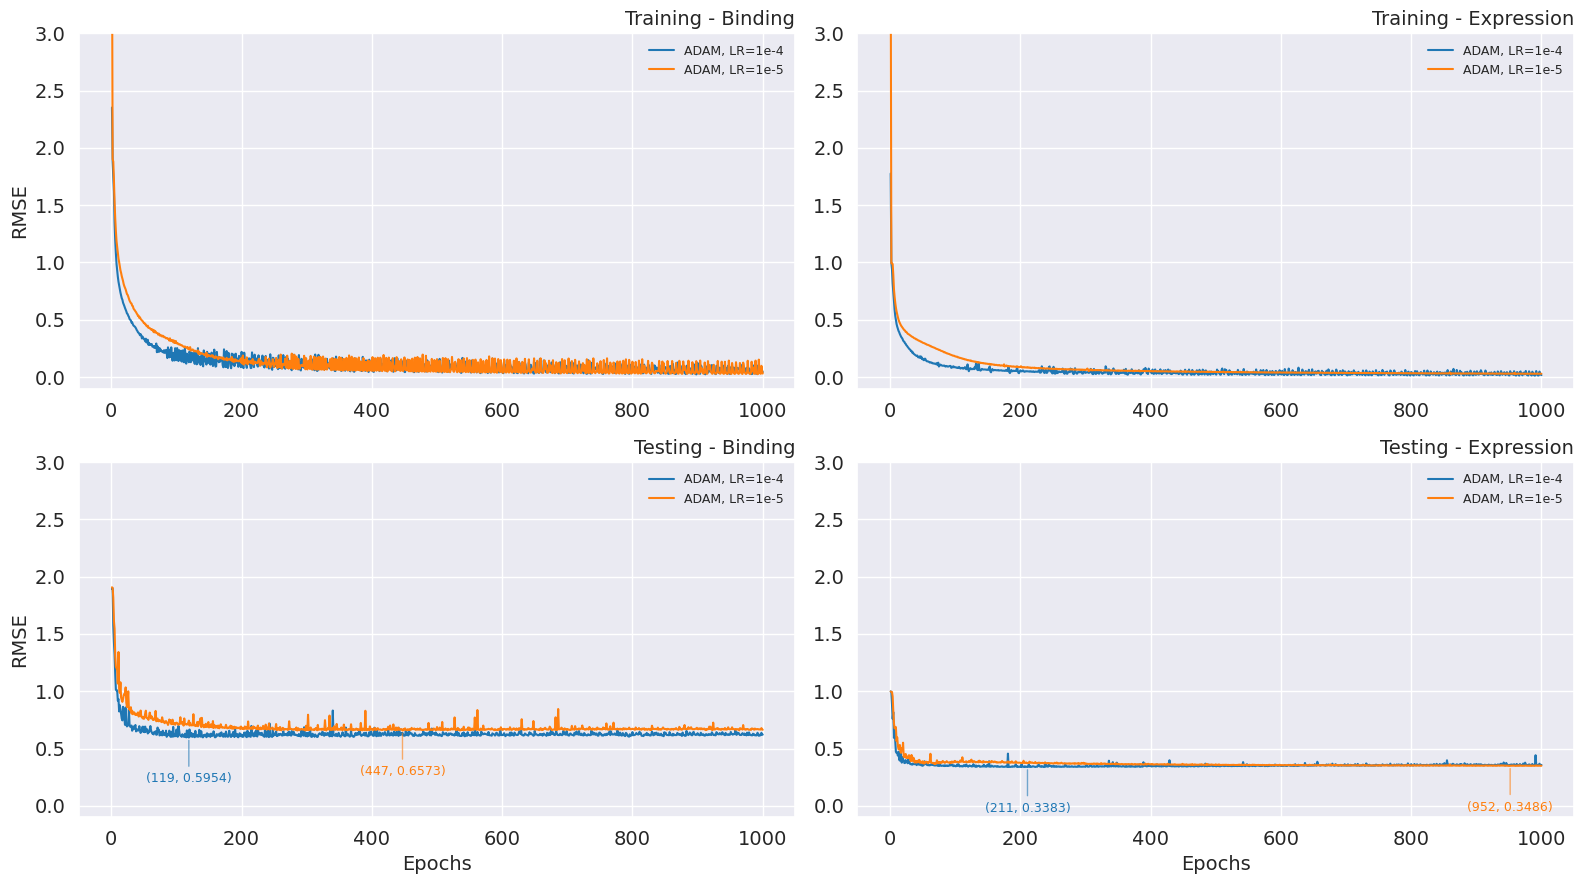

In [107]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-12-07_09-28/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-05.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-12-07_09-02/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-12-07_09-36/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-05.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-12-07_09-18/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm-bert_mlm_esm_init"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (0,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### FCN ESM-CLS Preembedded

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 271, rmse 1.2743
	ADAM, LR=1e-5: epoch 987, rmse 1.2238
- Expression:
	ADAM, LR=1e-4: epoch 397, rmse 0.6534
	ADAM, LR=1e-5: epoch 1000, rmse 0.6107


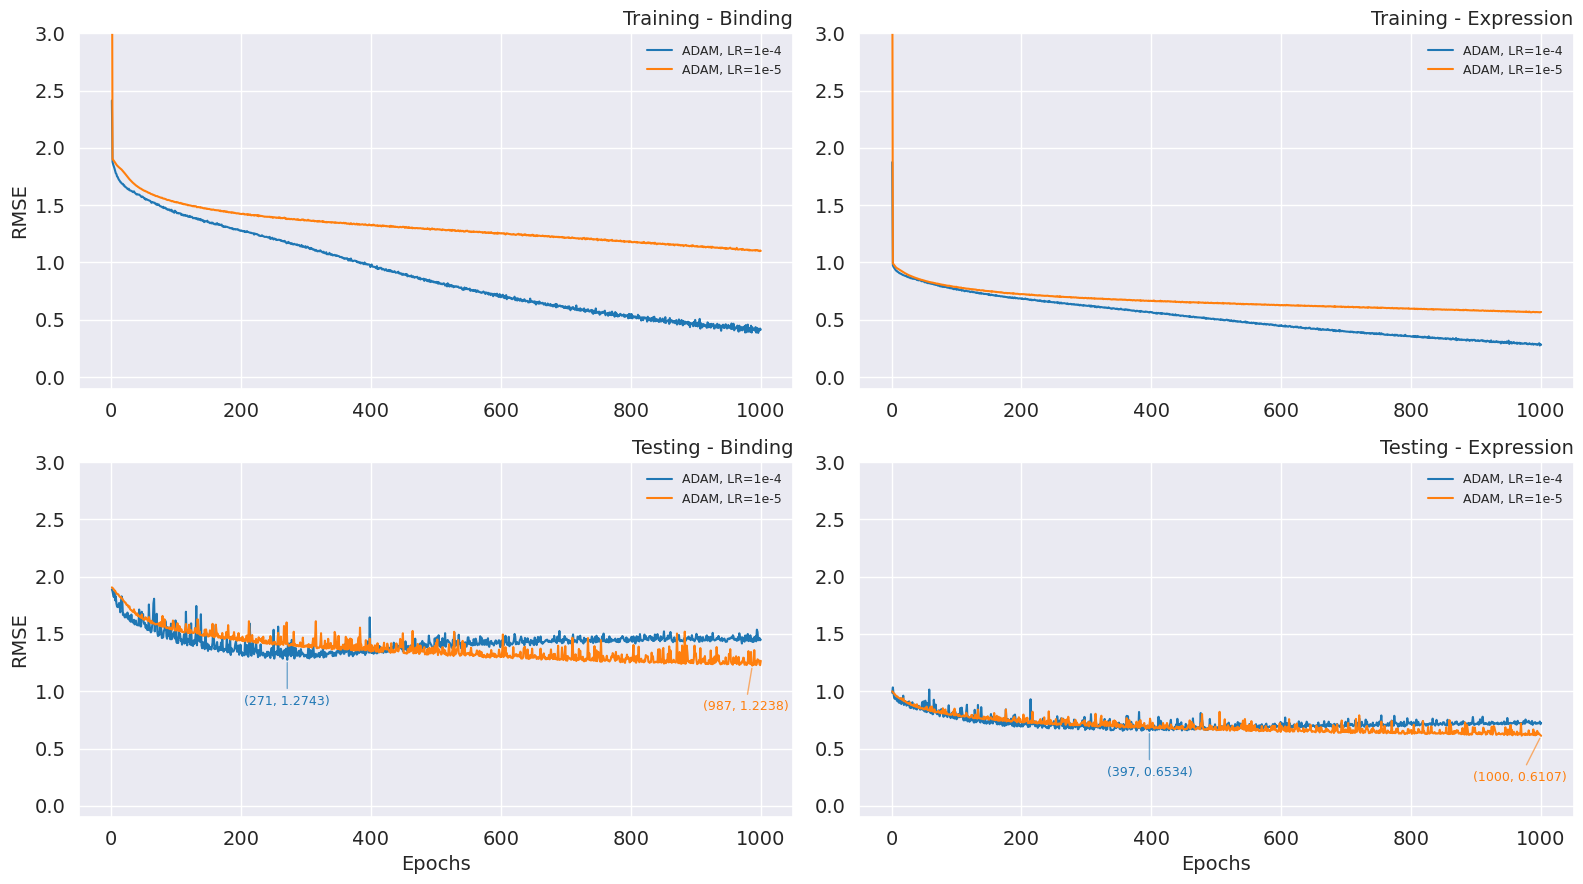

In [108]:
b_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-04.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-12-04_16-15/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-12-04_18-51/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-04.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-12-04_17-26/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-12-04_17-28/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/fcn-esm_cls_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (-5,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (-15,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM ESM-AA Preembedded

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 547, rmse 0.5518
	ADAM, LR=1e-5: epoch 971, rmse 0.5891
- Expression:
	ADAM, LR=1e-4: epoch 193, rmse 0.3335
	ADAM, LR=1e-5: epoch 946, rmse 0.3555


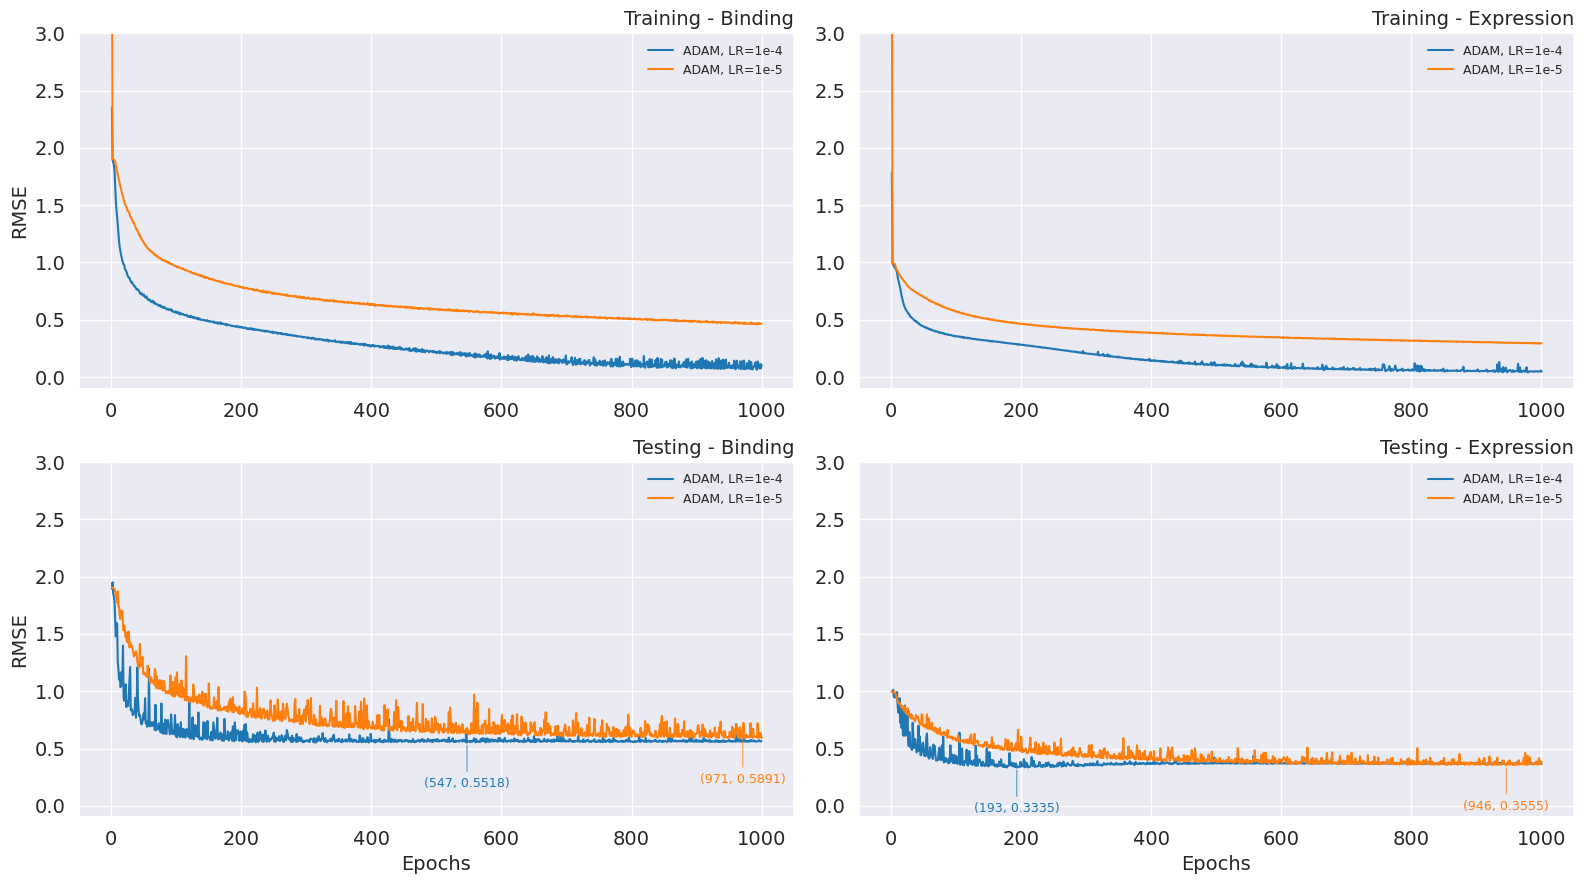

In [109]:
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-05/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-05.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-12-04_14-58/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_01-06/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-05.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-12-04_15-00/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-esm_aa_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-5": (0,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 946, rmse 1.9049
	ADAM, LR=1e-5: epoch 999, rmse 1.1148
- Expression:
	ADAM, LR=1e-4: epoch 676, rmse 0.9963
	ADAM, LR=1e-5: epoch 986, rmse 0.5834


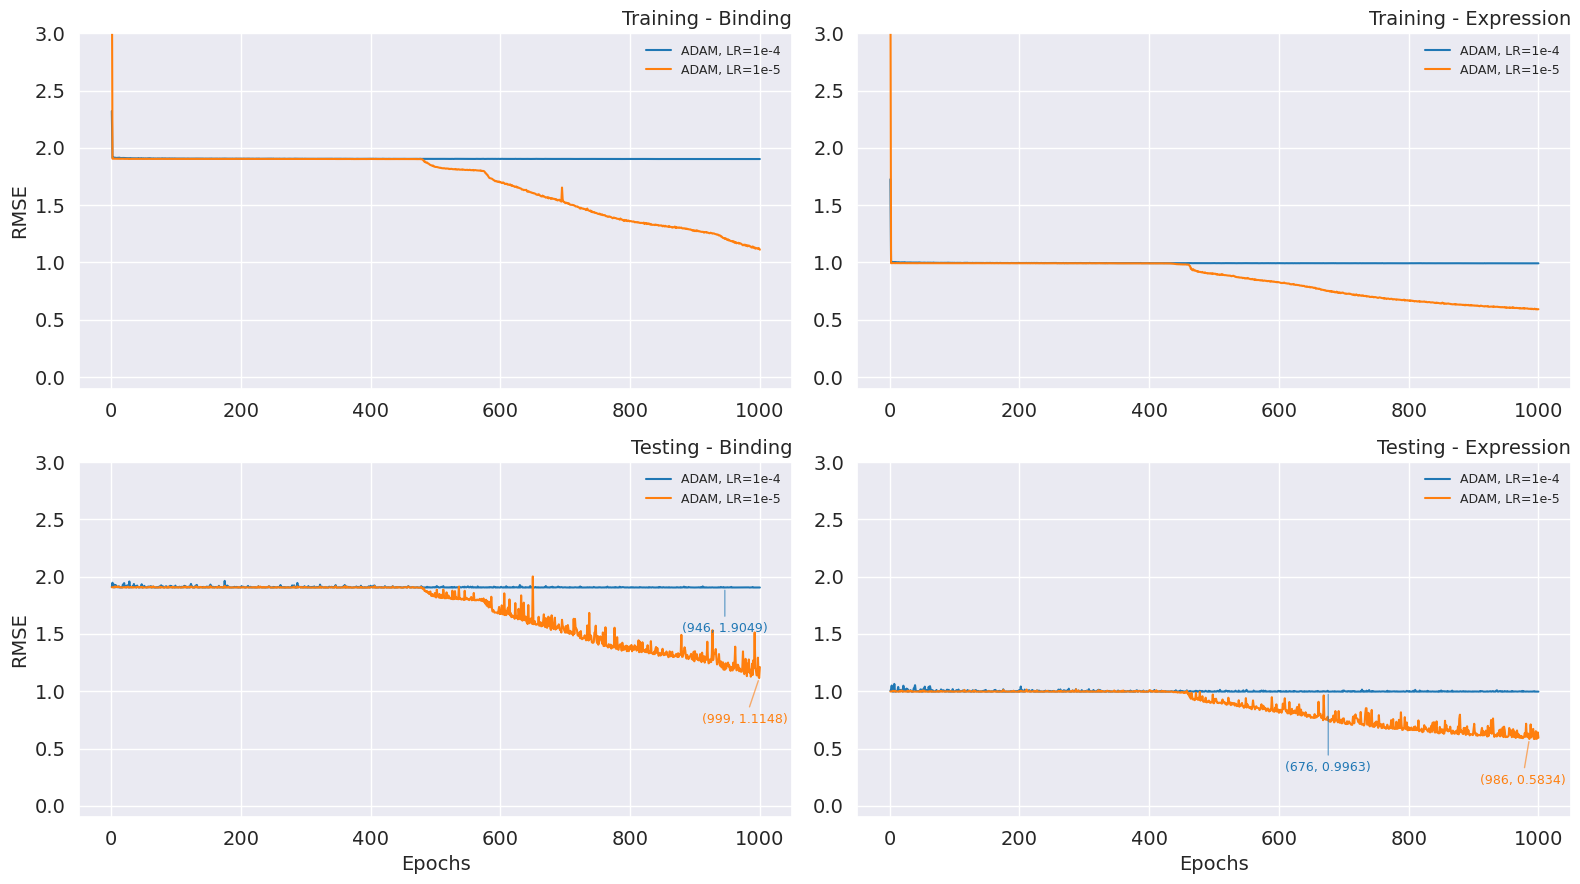

In [110]:
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-04.blstm-NLP_preembedded-DMS_OLD-binding-2024-12-05_11-05/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-binding-2024-12-05_04-05/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-04.blstm-NLP_preembedded-DMS_OLD-expression-2024-12-05_11-04/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-expression-2024-12-05_04-06/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-nlp_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (-10,-25),
    "E, ADAM, LR:1e-4": (0,-50),
    "E, ADAM, LR:1e-5": (-5,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### GCN ESM-AA Preembedded

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 997, rmse 1.0719
	ADAM, LR=1e-5: epoch 1000, rmse 1.2945
- Expression:
	ADAM, LR=1e-4: epoch 993, rmse 0.5409
	ADAM, LR=1e-5: epoch 997, rmse 0.6805


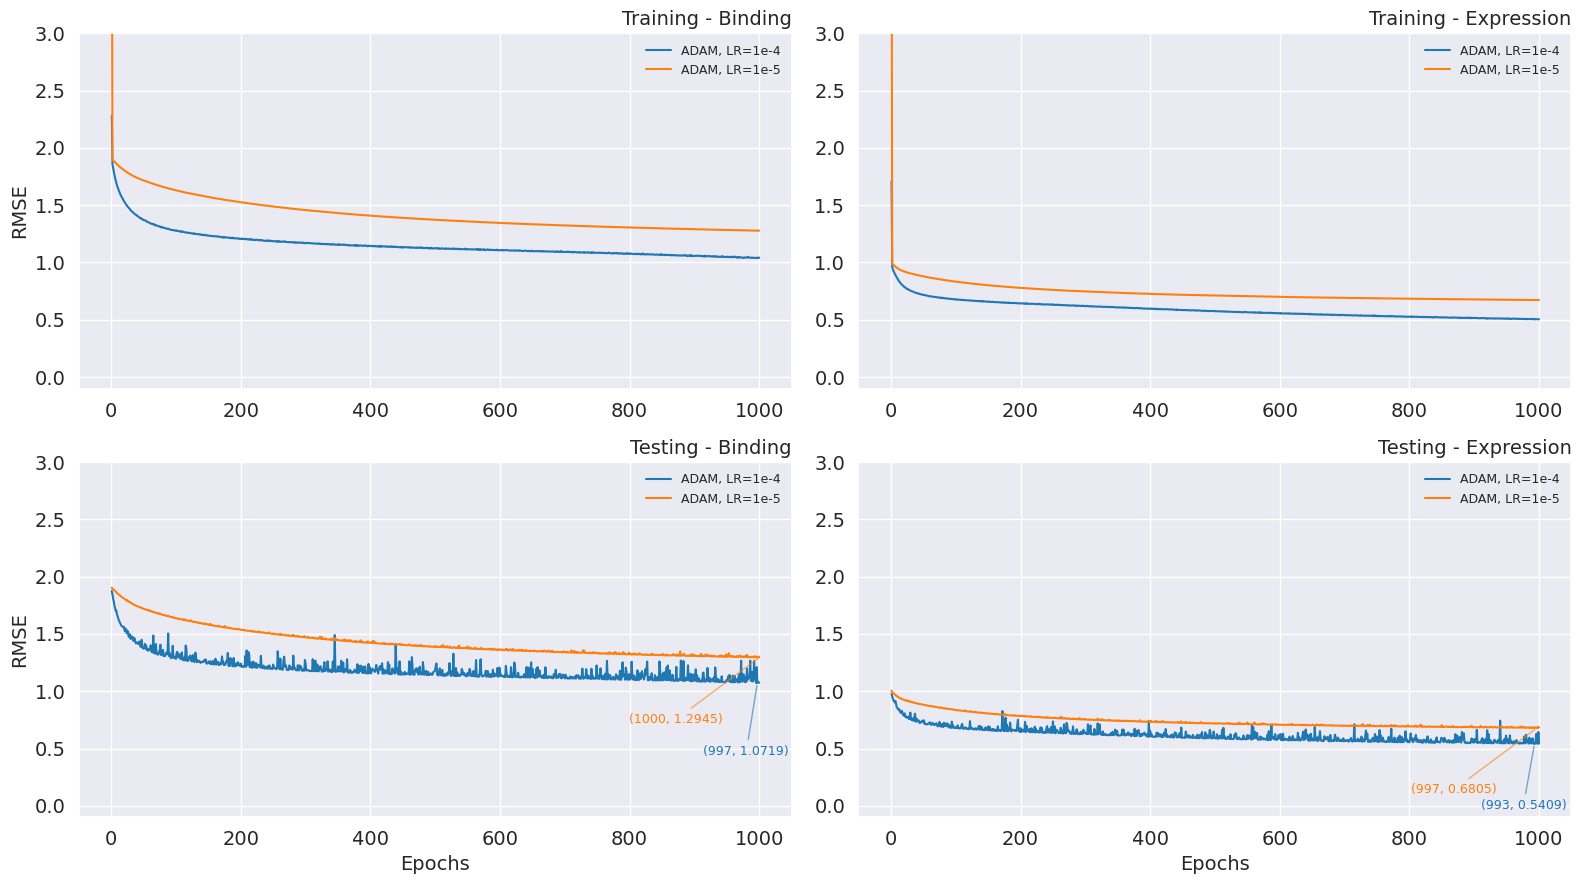

In [111]:
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-01/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-12-04_14-49/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_00-48/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-12-04_14-55/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.old"
coords = {
    "B, ADAM, LR:1e-4": (-8,-45),
    "B, ADAM, LR:1e-5": (-60,-40),
    "E, ADAM, LR:1e-4": (-8,-40),
    "E, ADAM, LR:1e-5": (-60,-40)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 553, rmse 0.8813
	ADAM, LR=1e-5: epoch 1000, rmse 1.1182
- Expression:
	ADAM, LR=1e-4: epoch 494, rmse 0.4759
	ADAM, LR=1e-5: epoch 995, rmse 0.5974


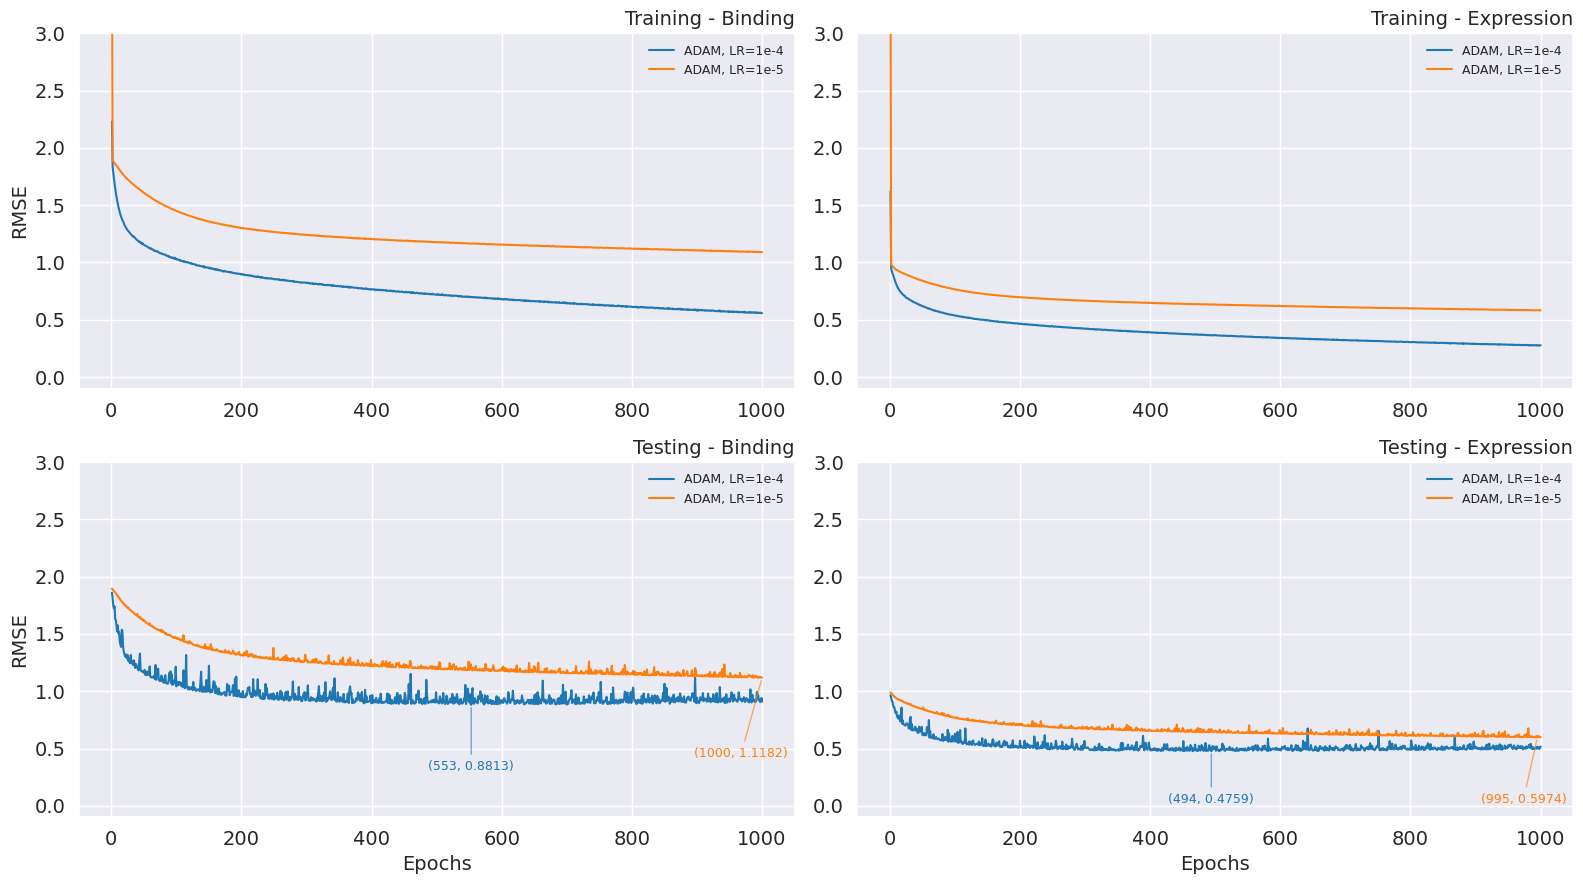

In [112]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-binding-2025-01-03_15-23/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-binding-2025-01-03_04-28/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-expression-2025-01-03_15-25/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-expression-2025-01-03_04-32/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-40),
    "B, ADAM, LR:1e-5": (-15,-50),
    "E, ADAM, LR:1e-4": (0,-30),
    "E, ADAM, LR:1e-5": (-10,-40)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

In [ ]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../"
b_adam_lr_1e_neg_5 = "../../"
e_adam_lr_1e_neg_4 = "../../"
e_adam_lr_1e_neg_5 = "../../"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-40),
    "B, ADAM, LR:1e-5": (-15,-50),
    "E, ADAM, LR:1e-4": (0,-30),
    "E, ADAM, LR:1e-5": (-10,-40)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### GCN NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 989, rmse 1.2092
	ADAM, LR=1e-5: epoch 998, rmse 1.3947
- Expression:
	ADAM, LR=1e-4: epoch 999, rmse 0.6670
	ADAM, LR=1e-5: epoch 1000, rmse 0.7479


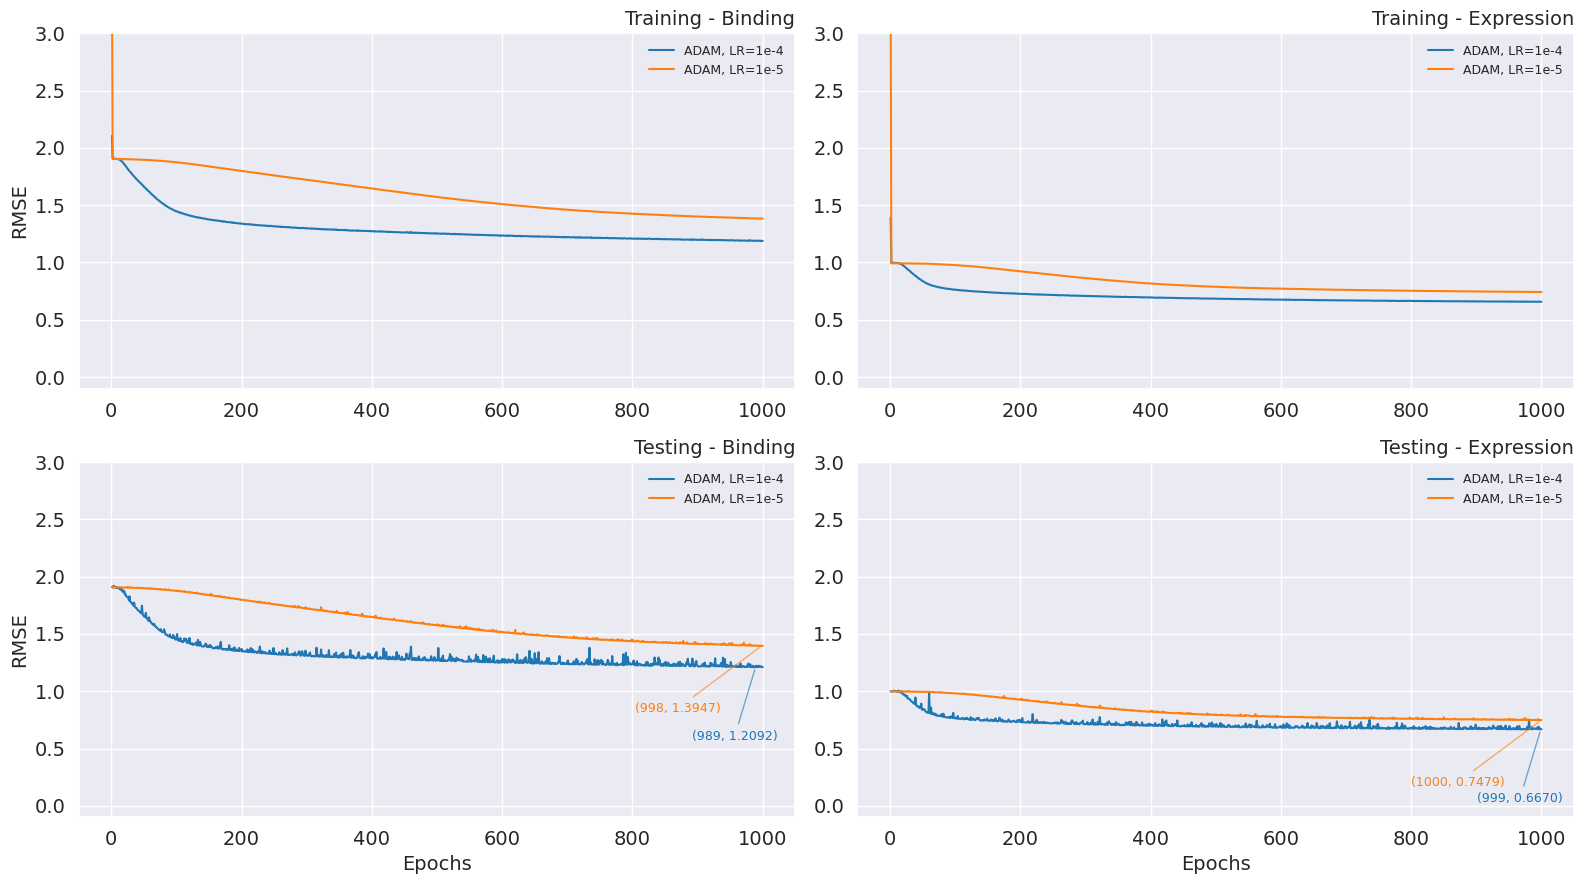

In [113]:
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-binding-2024-12-05_09-14/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-binding-2024-12-05_09-11/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-expression-2024-12-05_09-13/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-expression-2024-12-05_09-12/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.old"
coords = {
    "B, ADAM, LR:1e-4": (-15,-45),
    "B, ADAM, LR:1e-5": (-60,-40),
    "E, ADAM, LR:1e-4": (-15,-45),
    "E, ADAM, LR:1e-5": (-60,-40)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- Binding:
	ADAM, LR=1e-4: epoch 936, rmse 1.1454
	ADAM, LR=1e-5: epoch 994, rmse 1.1969
- Expression:
	ADAM, LR=1e-4: epoch 966, rmse 0.6499
	ADAM, LR=1e-5: epoch 992, rmse 0.6816


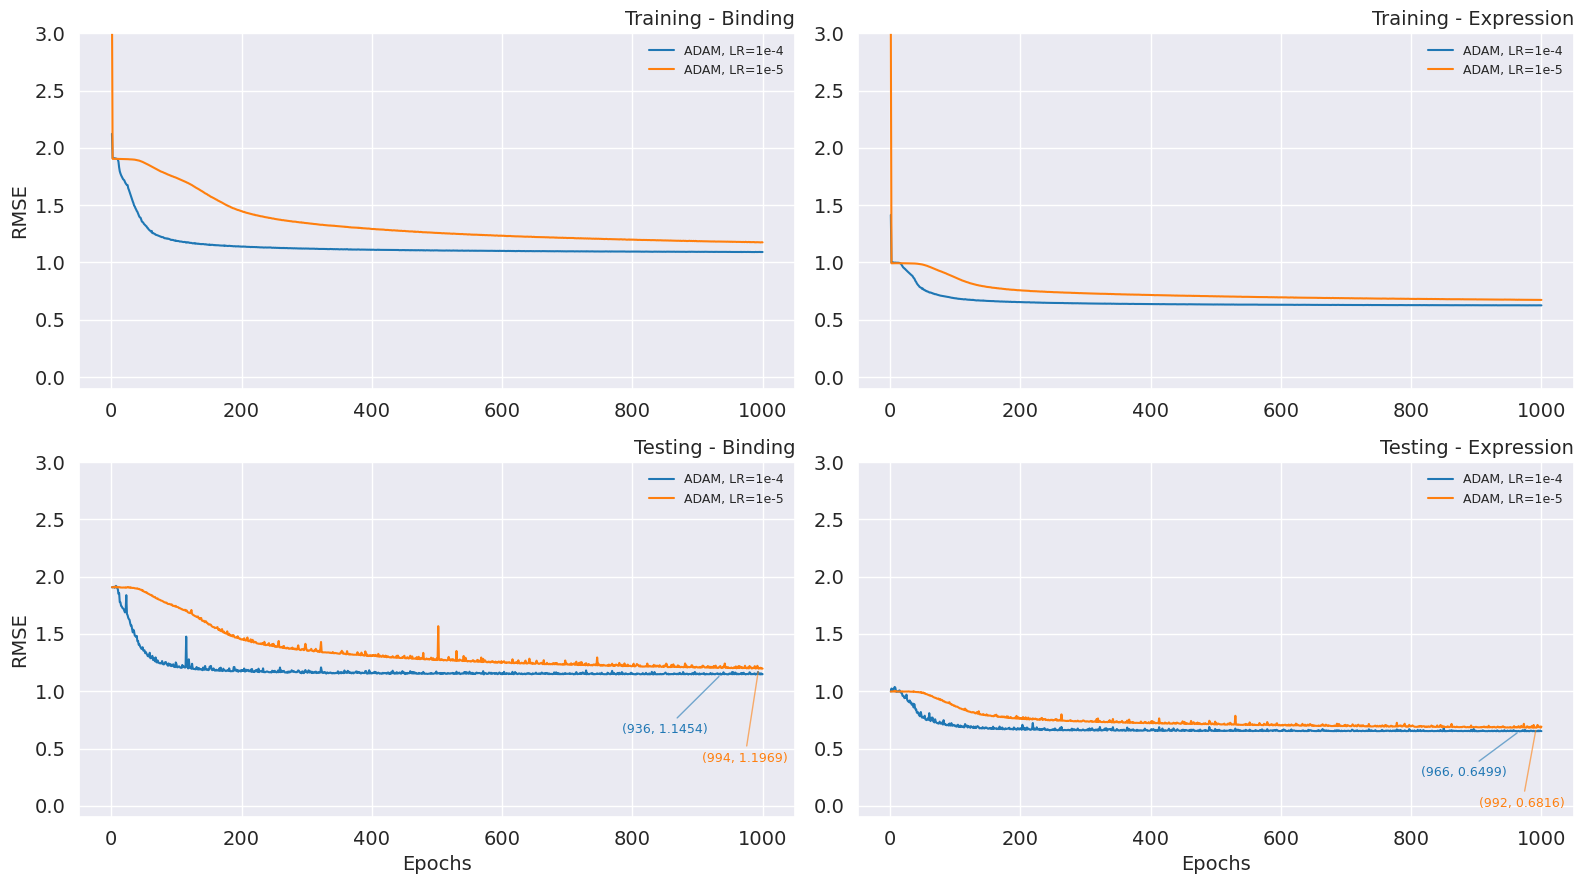

In [114]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-binding-2025-01-03_22-53/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-binding-2025-01-04_21-45/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-expression-2025-01-04_12-12/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-expression-2025-01-05_11-32/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.2relu"
coords = {
    "B, ADAM, LR:1e-4": (-40,-35),
    "B, ADAM, LR:1e-5": (-10,-60),
    "E, ADAM, LR:1e-4": (-40,-25),
    "E, ADAM, LR:1e-5": (-10,-50)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

In [ ]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../"
b_adam_lr_1e_neg_5 = "../../"
e_adam_lr_1e_neg_4 = "../../"
e_adam_lr_1e_neg_5 = "../../"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.1relu"
coords = {
    "B, ADAM, LR:1e-4": (-40,-35),
    "B, ADAM, LR:1e-5": (-10,-60),
    "E, ADAM, LR:1e-4": (-40,-25),
    "E, ADAM, LR:1e-5": (-10,-50)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")